### 1. Imports and Load Results

In [49]:
import json
from pathlib import Path

import time
import pickle
import random
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.utils.data      import Dataset, DataLoader, Subset
from sympy                  import nextprime, prime

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------------------------------------------------
# Plot style -- consistent across all figures in this notebook.
# Using a minimal style so plots are readable in both light and dark
# VSCode themes without hard-coding background colours.
# -----------------------------------------------------------------------

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10,
})

COLOUR_FP32    = '#2b7bb9'   # Blue for FP32 model
COLOUR_TERNARY = '#d95f02'   # Orange for ternary model

# -----------------------------------------------------------------------
# Configuration mirrors notebook 00.
# -----------------------------------------------------------------------

TASK_NAMES  = ['fibonacci', 'fizzbuzz', 'parity', 'primes']
EPOCHS      = 300
EVAL_EVERY  = 10
TERNARY_THRESH = 0.05

ROOT_DIR    = Path('..').resolve()
METRICS_DIR = ROOT_DIR / 'metrics'

# -----------------------------------------------------------------------
# Run selection -- set RUN_NAME to a specific folder name to load that
# run, or leave as None to automatically load the most recent run.
# Example: RUN_NAME = 'run_20240101_120000'
# -----------------------------------------------------------------------

RUN_NAME = None

if RUN_NAME is None:
    run_dirs = sorted([d for d in METRICS_DIR.iterdir() if d.is_dir() and d.name.startswith('run_')])
    if not run_dirs:
        raise FileNotFoundError(f'No run folders found in {METRICS_DIR}')
    RUN_DIR = run_dirs[-1]
else:
    RUN_DIR = METRICS_DIR / RUN_NAME

PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------
# Load the JSON metrics file produced by notebook 03.
# -----------------------------------------------------------------------

metrics_path = RUN_DIR / 'training_metrics.json'
with open(metrics_path) as f:
    M = json.load(f)

fp32_m    = M['fp32']
ternary_m = M['ternary']

epochs_range       = list(range(1, len(fp32_m['train_loss']) + 1))
fp32_epochs_range  = list(range(1, len(fp32_m['train_loss']) + 1))
tern_epochs_range  = list(range(1, len(ternary_m['train_loss']) + 1))
task_acc_epochs    = fp32_m['task_acc_epochs']
ternary_epochs     = ternary_m['ternary_epochs']

# print(f'Metrics loaded   : {metrics_path}')
print(f'Epochs recorded  : {len(epochs_range)}')
print(f'Eval checkpoints : {len(task_acc_epochs)}')

Epochs recorded  : 200
Eval checkpoints : 21


### 2. Loss Curves

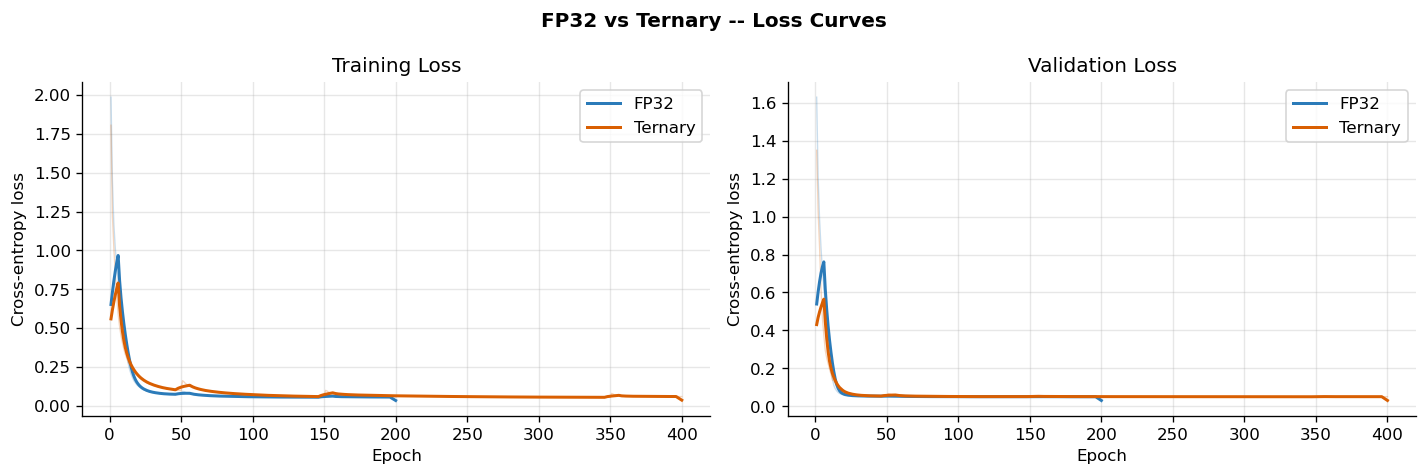

Metric                                     FP32     Ternary
------------------------------------------------------------
Final train loss                         0.0553      0.0584
Final val loss                           0.0496      0.0500
Best val loss (min)                      0.0495      0.0494
Epoch of best val loss                      196         332


In [50]:
# -----------------------------------------------------------------------
# Loss curves for both models on train and validation sets.
# Two panels: training loss (left) and validation loss (right).
# The smoothed line overlays the raw curve to make trends legible when
# the ternary loss is noisy early in training.
# -----------------------------------------------------------------------

def smooth(values, window=10):
    '''
    Simple moving-average smoothing over a list of scalar values.

    Parameters
    ----------
    values : list[float]
    window : int

    Returns
    -------
    numpy.ndarray
        Smoothed values, same length as input.
    '''
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='same')


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, metric_key, title in zip(axes, ['train_loss', 'val_loss'], ['Training Loss', 'Validation Loss']):

    fp32_vals    = fp32_m[metric_key]
    ternary_vals = ternary_m[metric_key]

    # Raw curves at low opacity as context
    ax.plot(fp32_epochs_range, fp32_vals,    color=COLOUR_FP32,    alpha=0.25, linewidth=0.8)
    ax.plot(tern_epochs_range, ternary_vals, color=COLOUR_TERNARY, alpha=0.25, linewidth=0.8)

    # Smoothed curves as the primary visual
    ax.plot(fp32_epochs_range, smooth(fp32_vals),    color=COLOUR_FP32,    linewidth=1.8, label='FP32')
    ax.plot(tern_epochs_range, smooth(ternary_vals), color=COLOUR_TERNARY, linewidth=1.8, label='Ternary')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend()

fig.suptitle('FP32 vs Ternary -- Loss Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'loss_curves.png', bbox_inches='tight')
plt.show()

# Numeric summary
print(f'{"Metric":<35}  {"FP32":>10}  {"Ternary":>10}')
print('-' * 60)
print(f'{"Final train loss":<35}  {fp32_m["train_loss"][-1]:>10.4f}  {ternary_m["train_loss"][-1]:>10.4f}')
print(f'{"Final val loss":<35}  {fp32_m["val_loss"][-1]:>10.4f}  {ternary_m["val_loss"][-1]:>10.4f}')
print(f'{"Best val loss (min)":<35}  {min(fp32_m["val_loss"]):>10.4f}  {min(ternary_m["val_loss"]):>10.4f}')
print(f'{"Epoch of best val loss":<35}  {np.argmin(fp32_m["val_loss"]) + 1:>10}  {np.argmin(ternary_m["val_loss"]) + 1:>10}')

### 3. Gradient Norm Comparison

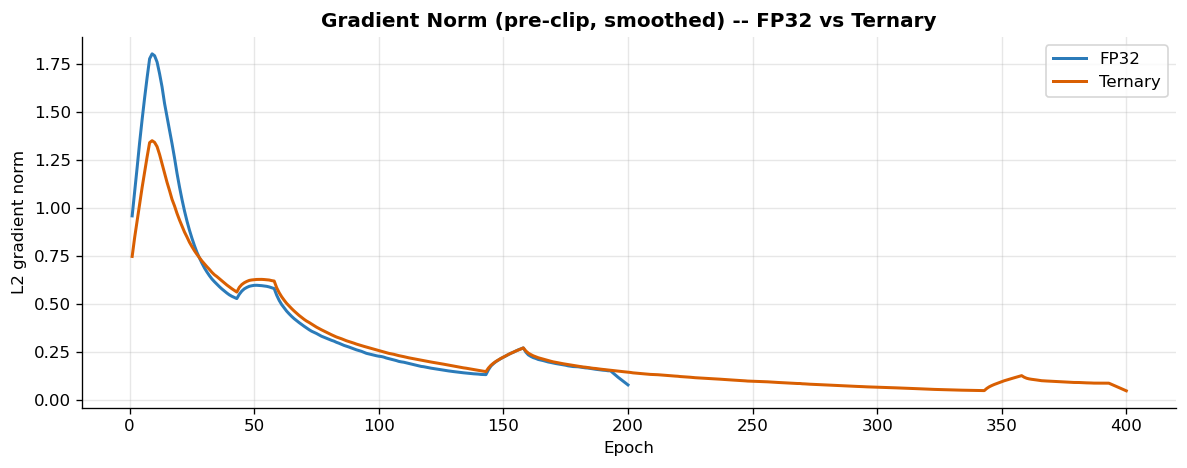

Metric                                          FP32     Ternary
-----------------------------------------------------------------
Mean grad norm (all epochs)                   0.4433      0.2551
Max  grad norm                                2.2773      1.6226
Grad norm std (volatility)                    0.4540      0.2953


In [51]:
# -----------------------------------------------------------------------
# Gradient norms reveal how much the straight-through estimator distorts
# the gradient signal relative to the FP32 model.
# Persistently higher norms in the ternary model indicate STE instability.
# -----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(fp32_epochs_range, smooth(fp32_m['grad_norm'],    15), color=COLOUR_FP32,    linewidth=1.8, label='FP32')
ax.plot(tern_epochs_range, smooth(ternary_m['grad_norm'], 15), color=COLOUR_TERNARY, linewidth=1.8, label='Ternary')

ax.set_title('Gradient Norm (pre-clip, smoothed) -- FP32 vs Ternary', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('L2 gradient norm')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'gradient_norms.png', bbox_inches='tight')
plt.show()

print(f'{"Metric":<40}  {"FP32":>10}  {"Ternary":>10}')
print('-' * 65)
print(f'{"Mean grad norm (all epochs)":<40}  {np.mean(fp32_m["grad_norm"]):>10.4f}  {np.mean(ternary_m["grad_norm"]):>10.4f}')
print(f'{"Max  grad norm":<40}  {max(fp32_m["grad_norm"]):>10.4f}  {max(ternary_m["grad_norm"]):>10.4f}')
print(f'{"Grad norm std (volatility)":<40}  {np.std(fp32_m["grad_norm"]):>10.4f}  {np.std(ternary_m["grad_norm"]):>10.4f}')

### 4. Per-Task Accuracy

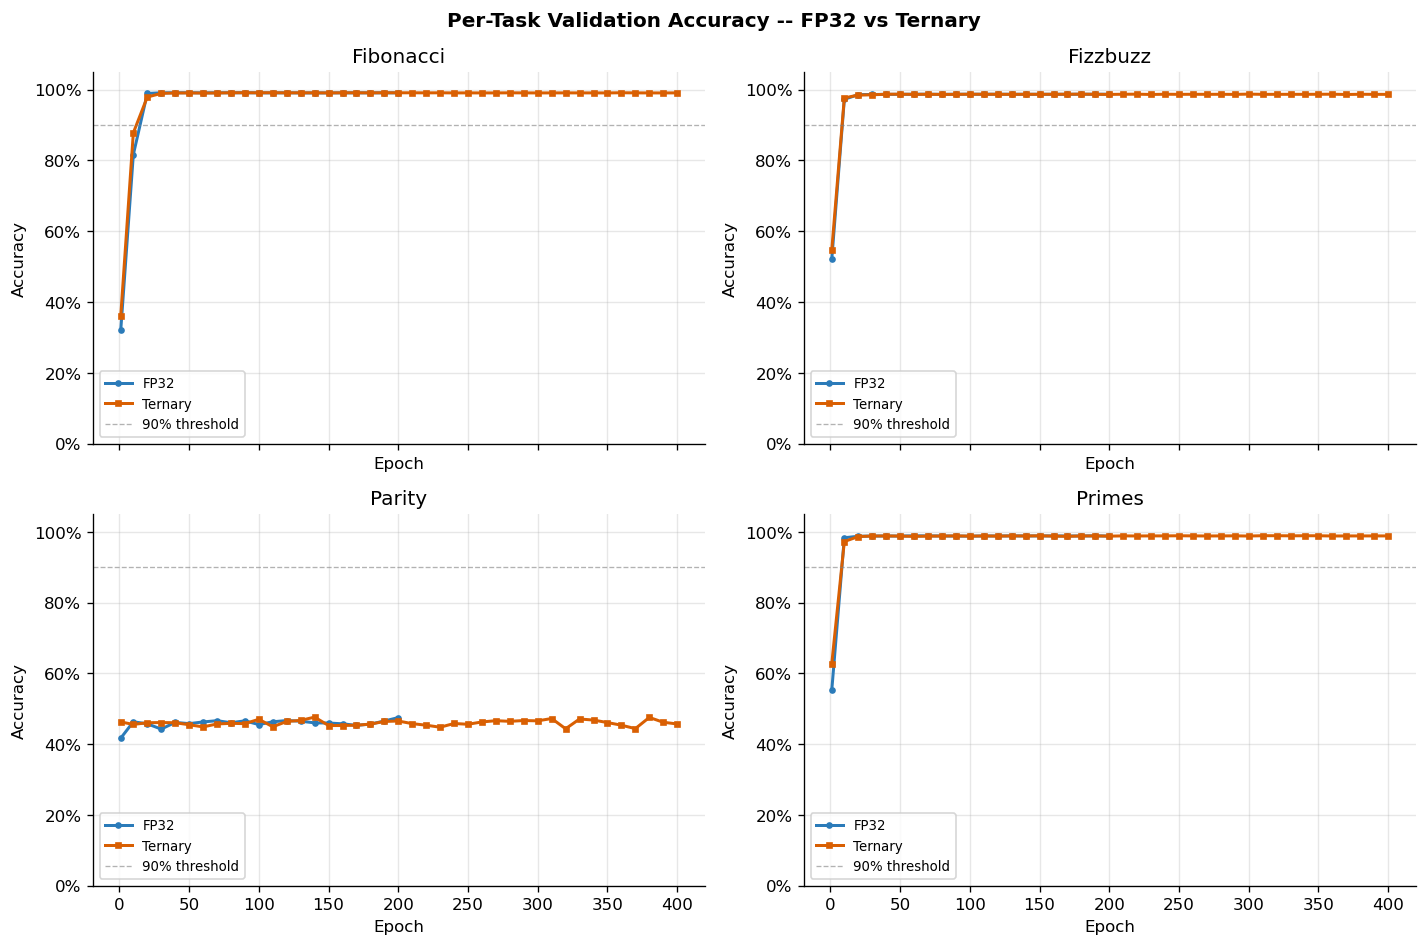

Task               FP32 final   Ternary final     Delta
-------------------------------------------------------
fibonacci              99.1%          99.1%     -0.0%
fizzbuzz               98.7%          98.7%     -0.0%
parity                 47.5%          45.7%     -1.8%
primes                 98.8%          98.8%     +0.0%


In [52]:
# -----------------------------------------------------------------------
# Per-task accuracy over the evaluation checkpoints.
# One subplot per task so the convergence trajectory is visible without
# lines overlapping across four different scales.
# -----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, TASK_NAMES):
    fp32_acc    = fp32_m['task_accuracy'][name]
    ternary_acc = ternary_m['task_accuracy'][name]

    ax.plot(task_acc_epochs, fp32_acc,    color=COLOUR_FP32,    linewidth=1.8, marker='o', markersize=3, label='FP32')
    ax.plot(ternary_epochs,  ternary_acc, color=COLOUR_TERNARY, linewidth=1.8, marker='s', markersize=3, label='Ternary')

    # Reference line at 90% accuracy for convergence threshold analysis
    ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='90% threshold')

    ax.set_title(name.capitalize())
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

fig.suptitle('Per-Task Validation Accuracy -- FP32 vs Ternary', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'per_task_accuracy.png', bbox_inches='tight')
plt.show()

# Final accuracy table
print(f'{"Task":<15}  {"FP32 final":>12}  {"Ternary final":>14}  {"Delta":>8}')
print('-' * 55)
for name in TASK_NAMES:
    f = fp32_m['task_accuracy'][name][-1]
    t = ternary_m['task_accuracy'][name][-1]
    print(f'{name:<15}  {f:>11.1%}  {t:>13.1%}  {t - f:>+8.1%}')

### 5. Ternary Weight Distribution

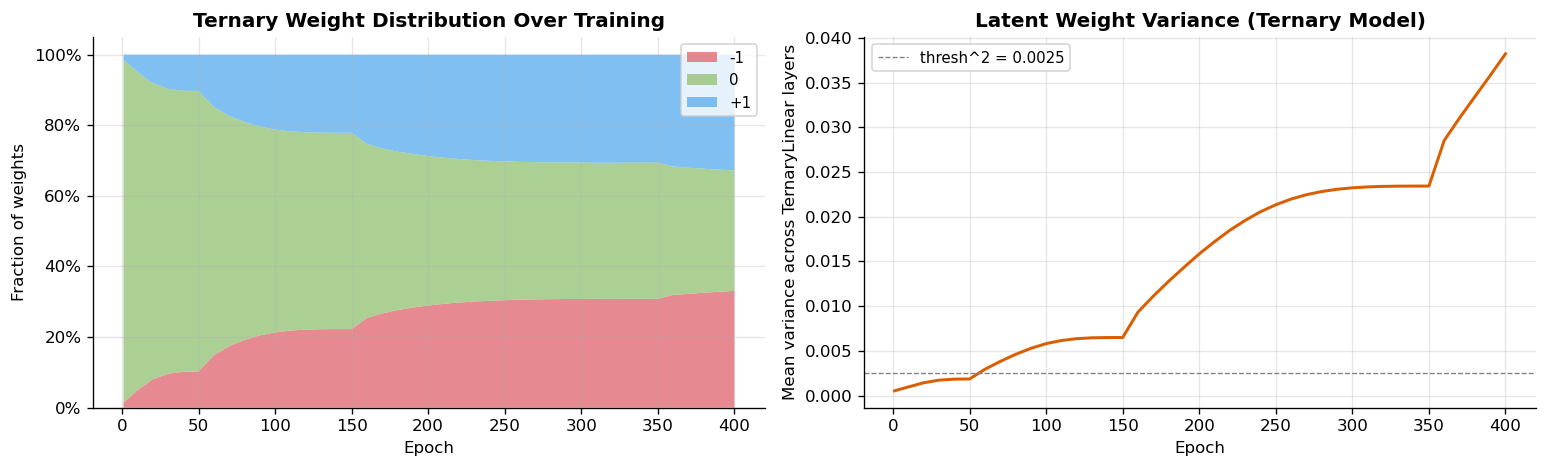

Final ternary weight distribution:
  -1 fraction : 0.331
   0 fraction : 0.341
  +1 fraction : 0.328
  Latent var  : 0.03822


In [53]:
# -----------------------------------------------------------------------
# Track how the fraction of weights at -1 / 0 / +1 evolves over training.
# Early training: most weights are near zero (high zero_frac).
# Later training: weights commit to -1 or +1 (zero_frac falls).
# A model where zero_frac never falls is functionally binary -- it never
# learned to use the zero value for selective suppression.
# -----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked area showing the three-way split over time
ax = axes[0]
neg1  = np.array(ternary_m['neg1_frac'])
zero  = np.array(ternary_m['zero_frac'])
pos1  = np.array(ternary_m['pos1_frac'])

ax.stackplot(
    ternary_epochs,
    neg1, zero, pos1,
    labels  = ['-1', '0', '+1'],
    colors  = ['#e06c75', '#98c379', '#61afef'],
    alpha   = 0.8,
)
ax.set_title('Ternary Weight Distribution Over Training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Fraction of weights')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper right', fontsize=9)

# Right: latent weight variance (indicator of how spread out the float
# values are -- high variance means weights are pushing hard against the
# threshold; low variance means they are clustered near zero)
ax = axes[1]
ax.plot(ternary_epochs, ternary_m['latent_var'], color=COLOUR_TERNARY, linewidth=1.8)
ax.axhline(TERNARY_THRESH ** 2, color='grey', linestyle='--', linewidth=0.8, label=f'thresh^2 = {TERNARY_THRESH**2:.4f}')
ax.set_title('Latent Weight Variance (Ternary Model)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean variance across TernaryLinear layers')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'ternary_weight_distribution.png', bbox_inches='tight')
plt.show()

print('Final ternary weight distribution:')
print(f'  -1 fraction : {neg1[-1]:.3f}')
print(f'   0 fraction : {zero[-1]:.3f}')
print(f'  +1 fraction : {pos1[-1]:.3f}')
print(f'  Latent var  : {ternary_m["latent_var"][-1]:.5f}')

### 6. Weight Churn Analysis

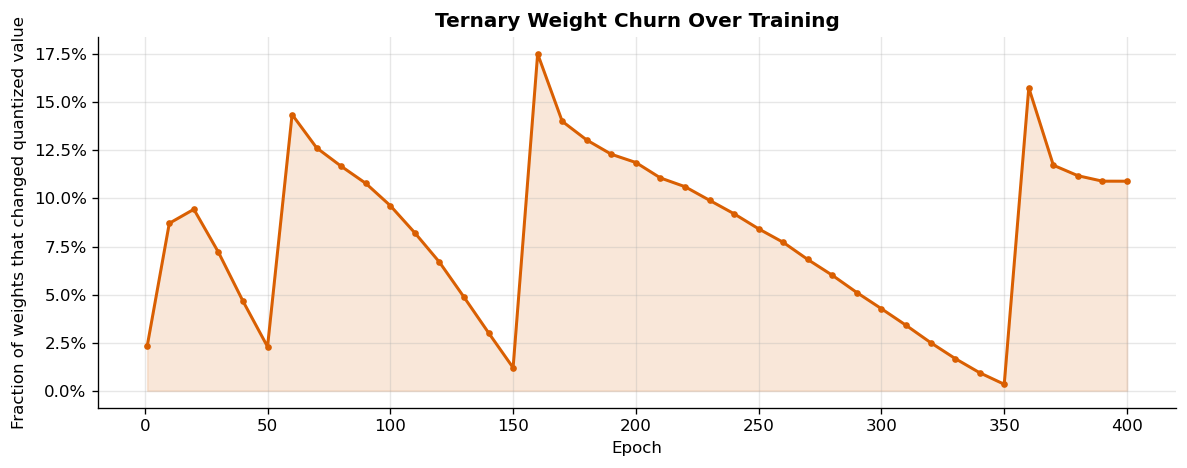

Peak churn epoch  : 160  (0.175)
Final churn       : 0.1090
Churn halving     : epoch where churn first dropped below 0.088 after the peak
> epoch 250


In [54]:
# -----------------------------------------------------------------------
# Weight churn is the fraction of ternary weights that changed their
# quantized value (e.g. 0 -> +1) between two consecutive evaluation
# checkpoints. It is a proxy for training stability:
#   High early churn  -- expected; model is still learning
#   Falling churn     -- weights are settling into stable ternary values
#   Near-zero churn   -- model has effectively converged
#   Persistent churn  -- STE instability, possibly needs LR adjustment
# -----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ternary_epochs, ternary_m['weight_churn'], color=COLOUR_TERNARY, linewidth=1.8, marker='o', markersize=3)
ax.fill_between(ternary_epochs, ternary_m['weight_churn'], alpha=0.15, color=COLOUR_TERNARY)

ax.set_title('Ternary Weight Churn Over Training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Fraction of weights that changed quantized value')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'weight_churn.png', bbox_inches='tight')
plt.show()

churn_arr   = np.array(ternary_m['weight_churn'])
peak_idx    = int(np.argmax(churn_arr))
peak_epoch  = ternary_epochs[peak_idx]
peak_churn  = churn_arr[peak_idx]
half_peak   = peak_churn / 2

print(f'Peak churn epoch  : {peak_epoch}  ({peak_churn:.3f})')
print(f'Final churn       : {churn_arr[-1]:.4f}')
print(f'Churn halving     : epoch where churn first dropped below {half_peak:.3f} after the peak')

# Search only after the peak to avoid pre-cascade values which are
# low by definition and would produce a misleading result
post_peak_churn  = churn_arr[peak_idx:]
post_peak_epochs = ternary_epochs[peak_idx:]
below = [e for c, e in zip(post_peak_churn, post_peak_epochs) if c < half_peak]
print(f'> epoch {below[0] if below else "not reached"}')

### 7. Convergence Analysis

In [55]:
# -----------------------------------------------------------------------
# Convergence speed: for each task, find the first evaluation epoch at
# which each model first exceeded 80% and 90% accuracy.
# A model that reaches 90% faster is more sample-efficient for that task.
# -----------------------------------------------------------------------

THRESHOLDS = [0.50, 0.80, 0.90]

print('Epoch at which each model first exceeded accuracy threshold:')
print()

for thresh in THRESHOLDS:
    print(f'Threshold : {thresh:.0%}')
    print(f'  {"Task":<15}  {"FP32 epoch":>12}  {"Ternary epoch":>14}')
    print('  ' + '-' * 45)

    for name in TASK_NAMES:
        fp32_epochs_above    = [e for e, a in zip(task_acc_epochs, fp32_m['task_accuracy'][name])    if a >= thresh]
        ternary_epochs_above = [e for e, a in zip(ternary_epochs,  ternary_m['task_accuracy'][name]) if a >= thresh]

        fp32_first    = fp32_epochs_above[0]    if fp32_epochs_above    else 'never'
        ternary_first = ternary_epochs_above[0] if ternary_epochs_above else 'never'

        print(f'  {name:<15}  {str(fp32_first):>12}  {str(ternary_first):>14}')

    print()

# -----------------------------------------------------------------------
# Epoch time comparison -- how much slower is ternary on CPU vs FP32?
# -----------------------------------------------------------------------

fp32_mean_time    = np.mean(fp32_m['epoch_time_s'])
ternary_mean_time = np.mean(ternary_m['epoch_time_s'])
total_fp32        = sum(fp32_m['epoch_time_s'])
total_ternary     = sum(ternary_m['epoch_time_s'])

print('Epoch timing (training only, CPU):')
print(f'  FP32    mean : {fp32_mean_time:.3f}s  |  total: {total_fp32 / 60:.1f} min')
print(f'  Ternary mean : {ternary_mean_time:.3f}s  |  total: {total_ternary / 60:.1f} min')
print(f'  Ratio        : {ternary_mean_time / fp32_mean_time:.2f}x  (>1 means ternary is slower during training)')
print()
print('Note: ternary is typically slower to TRAIN because STE overhead exceeds')
print('the saving from integer weights. The inference speed gain is separate')
print('and only materialises with purpose-built ternary kernels.')

Epoch at which each model first exceeded accuracy threshold:

Threshold : 50%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  10              10
  fizzbuzz                    1               1
  parity                  never           never
  primes                      1               1

Threshold : 80%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  10              10
  fizzbuzz                   10              10
  parity                  never           never
  primes                     10              10

Threshold : 90%
  Task               FP32 epoch   Ternary epoch
  ---------------------------------------------
  fibonacci                  20              20
  fizzbuzz                   10              10
  parity                  never           never
  primes                     10              10

Epoch timing (training 

### 8. Summary Table

In [56]:
# -----------------------------------------------------------------------
# Full comparison table -- one row per metric, FP32 and ternary columns.
# Delta column shows ternary - FP32 for numeric metrics so the sign
# makes the direction of difference immediately readable.
# -----------------------------------------------------------------------

SEP = '-' * 70

print(SEP)
print(f'{"METRIC":<38}  {"FP32":>10}  {"TERNARY":>10}  {"DELTA":>8}')
print(SEP)

def row(label, fp32_val, tern_val, fmt='.4f', delta=True):
    d = f'{tern_val - fp32_val:+.4f}' if delta else ''
    print(f'{label:<38}  {fp32_val:>10{fmt}}  {tern_val:>10{fmt}}  {d:>8}')


# Loss
row('Final train loss',      fp32_m['train_loss'][-1],  ternary_m['train_loss'][-1])
row('Final val loss',        fp32_m['val_loss'][-1],    ternary_m['val_loss'][-1])
row('Best val loss',         min(fp32_m['val_loss']),   min(ternary_m['val_loss']))

print()

# Gradient
row('Mean grad norm',        np.mean(fp32_m['grad_norm']),  np.mean(ternary_m['grad_norm']))
row('Grad norm std',         np.std(fp32_m['grad_norm']),   np.std(ternary_m['grad_norm']))

print()

# Per-task accuracy
for name in TASK_NAMES:
    row(
        f'Final accuracy -- {name}',
        fp32_m['task_accuracy'][name][-1],
        ternary_m['task_accuracy'][name][-1],
        fmt='.3f',
    )

print()

# Speed
row('Mean epoch time (s)',   fp32_mean_time, ternary_mean_time, fmt='.3f')
row('Total train time (s)',  total_fp32,     total_ternary,     fmt='.1f')

print()

# Ternary-only metrics (no FP32 equivalent)
print(f'{"TERNARY-ONLY METRICS":<38}')
print(SEP)
print(f'{"Final -1 weight fraction":<38}  {ternary_m["neg1_frac"][-1]:>10.3f}')
print(f'{"Final  0 weight fraction":<38}  {ternary_m["zero_frac"][-1]:>10.3f}')
print(f'{"Final +1 weight fraction":<38}  {ternary_m["pos1_frac"][-1]:>10.3f}')
print(f'{"Final weight churn":<38}  {ternary_m["weight_churn"][-1]:>10.4f}')
print(f'{"Final latent weight variance":<38}  {ternary_m["latent_var"][-1]:>10.5f}')

print(SEP)
print()
#  print(f'Plots saved to: {PLOT_DIR}')

----------------------------------------------------------------------
METRIC                                        FP32     TERNARY     DELTA
----------------------------------------------------------------------
Final train loss                            0.0553      0.0584   +0.0031
Final val loss                              0.0496      0.0500   +0.0004
Best val loss                               0.0495      0.0494   -0.0002

Mean grad norm                              0.4433      0.2551   -0.1881
Grad norm std                               0.4540      0.2953   -0.1587

Final accuracy -- fibonacci                  0.991       0.991   -0.0001
Final accuracy -- fizzbuzz                   0.987       0.987   -0.0003
Final accuracy -- parity                     0.475       0.457   -0.0180
Final accuracy -- primes                     0.988       0.988   +0.0003

Mean epoch time (s)                         45.204      43.518   -1.6856
Total train time (s)                        9040.7  

### 9. Inference Speed and Memory Footprint

In [57]:
# -----------------------------------------------------------------------
# Load run config so all architectural constants match the current run
# exactly rather than being hardcoded and potentially stale.
# -----------------------------------------------------------------------

with open(RUN_DIR / 'run_config.json') as f:
    run_config = json.load(f)

VOCAB_SIZE     = run_config['vocab_size']
SEQ_LEN        = run_config['seq_len']
EMBED_DIM      = run_config['embed_dim']
NUM_HEADS      = run_config['num_heads']
NUM_LAYERS     = run_config['num_layers']
FF_DIM         = run_config['ff_dim']
DROPOUT        = run_config['dropout']
TERNARY_THRESH = run_config['ternary_thresh']

TOK_PAD  = 14
TOK_SEP  = 13
TOK_FIZZ = 10
TOK_BUZZ = 11
TOK_FZBZ = 12

if torch.backends.mps.is_available():
    INFER_DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    INFER_DEVICE = torch.device('cuda')
else:
    INFER_DEVICE = torch.device('cpu')

N_INFERENCE_RUNS = 20

print(f'Run config loaded  : {RUN_DIR.name}')
print(f'Architecture       : embed={EMBED_DIM}  heads={NUM_HEADS}  layers={NUM_LAYERS}  ff={FF_DIM}')
print(f'Device             : {INFER_DEVICE}')

Run config loaded  : run_20260316_215631
Architecture       : embed=128  heads=8  layers=8  ff=256
Device             : mps


In [58]:
# -----------------------------------------------------------------------
# Model definitions -- redefined here so this notebook loads checkpoints
# without depending on notebook 03 being in memory.
# -----------------------------------------------------------------------

import torch.nn            as nn
import torch.nn.functional as F


class TernaryLinear(nn.Linear):
    '''
    nn.Linear replacement with ternary weight quantization and STE.
    Redefined here for checkpoint loading -- see notebook 02 for full docs.
    '''
    def __init__(self, in_features, out_features, bias=True):
        super().__init__(in_features, out_features, bias)

    def quantize(self):
        w = self.weight
        q = torch.sign(w) * (w.abs() > TERNARY_THRESH).float()
        return w + (q - w).detach()

    def forward(self, x):
        return F.linear(x, self.quantize(), self.bias)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout, linear_cls=nn.Linear):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff1   = linear_cls(embed_dim, ff_dim)
        self.ff2   = linear_cls(ff_dim, embed_dim)
        self.act   = nn.GELU()
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        h    = self.norm1(x)
        h, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x    = x + self.drop(h)
        h    = self.norm2(x)
        h    = self.drop(self.act(self.ff1(h)))
        h    = self.ff2(h)
        x    = x + self.drop(h)
        return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, embed_dim, num_heads,
                 num_layers, ff_dim, dropout, linear_cls=nn.Linear):
        super().__init__()
        self.tok_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=TOK_PAD)
        self.pos_embed = nn.Embedding(seq_len,    embed_dim)
        self.layers    = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout, linear_cls)
            for _ in range(num_layers)
        ])
        self.norm      = nn.LayerNorm(embed_dim)
        self.output    = nn.Linear(embed_dim, vocab_size, bias=False)
        self.seq_len   = seq_len
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device).unsqueeze(0)
        h    = self.tok_embed(x) + self.pos_embed(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        for layer in self.layers:
            h = layer(h, attn_mask=mask)
        return self.output(self.norm(h))


print('Model classes defined.')

Model classes defined.


In [ ]:
# -----------------------------------------------------------------------
# Load checkpoints from the current run directory.
# -----------------------------------------------------------------------

CKPT_DIR_RUN = ROOT_DIR / 'checkpoints' / RUN_DIR.name

MODEL_KWARGS = dict(
    vocab_size = VOCAB_SIZE,
    seq_len    = SEQ_LEN,
    embed_dim  = EMBED_DIM,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    ff_dim     = FF_DIM,
    dropout    = DROPOUT,
)

fp32_model    = TinyTransformer(**MODEL_KWARGS, linear_cls=nn.Linear).to(INFER_DEVICE)
ternary_model = TinyTransformer(**MODEL_KWARGS, linear_cls=TernaryLinear).to(INFER_DEVICE)

fp32_model.load_state_dict(torch.load(CKPT_DIR_RUN / 'fp32_model.pt',    map_location=INFER_DEVICE))
ternary_model.load_state_dict(torch.load(CKPT_DIR_RUN / 'ternary_model.pt', map_location=INFER_DEVICE))

fp32_model.eval()
ternary_model.eval()

n_params = sum(p.numel() for p in fp32_model.parameters())
print(f'Checkpoints loaded : {CKPT_DIR_RUN}')
print(f'Parameters         : {n_params:,}')

In [60]:
# -----------------------------------------------------------------------
# Load val dataset -- redefined generators needed for unpickling.
# -----------------------------------------------------------------------

from sympy import nextprime, prime as sympy_prime


def int_to_tokens(n):
    return [int(d) for d in str(n)]

def fizzbuzz_tokens(n):
    if n % 15 == 0: return [TOK_FZBZ]
    if n % 3  == 0: return [TOK_FIZZ]
    if n % 5  == 0: return [TOK_BUZZ]
    return int_to_tokens(n)

def gen_fibonacci(target_len):
    a, b = random.randint(0, 9), random.randint(0, 9)
    out  = []
    while len(out) < target_len:
        out.extend(int_to_tokens(a % 1000))
        out.append(TOK_SEP)
        a, b = b, (a + b) % 1000
    return out

def gen_fizzbuzz(target_len):
    n, out = random.randint(1, 200), []
    while len(out) < target_len:
        out.extend(fizzbuzz_tokens(n))
        out.append(TOK_SEP)
        n += 1
    return out

def gen_parity(target_len):
    length = random.randint(4, 14)
    bits   = [random.randint(0, 1) for _ in range(length)]
    parity = sum(bits) % 2
    out    = bits + [TOK_SEP, parity]
    out    = out + [TOK_PAD] * (target_len - len(out))
    return out

def gen_primes(target_len):
    p, out = sympy_prime(random.randint(1, 100)), []
    while len(out) < target_len:
        out.extend(int_to_tokens(p))
        out.append(TOK_SEP)
        p = nextprime(p)
    return out

TASK_NAMES_INFER = ['fibonacci', 'fizzbuzz', 'parity', 'primes']

TASK_GENERATORS_INFER = {
    'fibonacci': gen_fibonacci,
    'fizzbuzz' : gen_fizzbuzz,
    'parity'   : gen_parity,
    'primes'   : gen_primes,
}


class SyntheticTaskDataset(Dataset):
    '''
    Redefined for unpickling -- see notebook 01 for full documentation.
    '''
    def __init__(self, n_samples, seq_len, seed=42):
        super().__init__()
        self.seq_len = seq_len
        per_task     = n_samples // len(TASK_NAMES_INFER)
        local_rng    = random.Random(seed)
        samples, labels = [], []
        for task_idx, name in enumerate(TASK_NAMES_INFER):
            gen = TASK_GENERATORS_INFER[name]
            for _ in range(per_task):
                tokens = gen(seq_len + 1)
                if len(tokens) < seq_len + 1:
                    tokens = tokens + [TOK_PAD] * (seq_len + 1 - len(tokens))
                samples.append(tokens[: seq_len + 1])
                labels.append(task_idx)
        combined = list(zip(samples, labels))
        local_rng.shuffle(combined)
        samples, labels  = zip(*combined)
        self.samples     = [torch.tensor(s, dtype=torch.long) for s in samples]
        self.labels      = list(labels)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tokens = self.samples[idx]
        return tokens[:-1], tokens[1:], self.labels[idx]


from torch.utils.data import Dataset, Subset, DataLoader

data_path = ROOT_DIR / 'data' / 'synthetic_dataset.pkl'
with open(data_path, 'rb') as f:
    saved = pickle.load(f)

val_ds     = Subset(saved['dataset'], saved['val_indices'])
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)

print(f'Val samples loaded : {len(val_ds)}')

Val samples loaded : 1000


In [61]:
# -----------------------------------------------------------------------
# Inference speed -- mean forward pass time per token over the val set,
# averaged over N_INFERENCE_RUNS passes to reduce timing noise.
# -----------------------------------------------------------------------

def measure_inference_speed(model, loader, n_runs):
    '''
    Measure mean forward pass time per token over the val set.

    Parameters
    ----------
    model   : nn.Module
    loader  : DataLoader
    n_runs  : int

    Returns
    -------
    tuple[float, float]
        (mean_ms_per_batch, mean_us_per_token)
    '''
    model.eval()
    total_time   = 0.0
    total_tokens = 0
    n_batches    = 0

    with torch.no_grad():
        for _ in range(n_runs):
            for x, y, _ in loader:
                x       = x.to(INFER_DEVICE)
                t0      = time.perf_counter()
                _       = model(x)
                elapsed = time.perf_counter() - t0
                total_time   += elapsed
                total_tokens += x.numel()
                n_batches    += 1

    mean_ms_per_batch = (total_time / (n_runs * n_batches)) * 1000
    mean_us_per_token = (total_time / total_tokens) * 1e6
    return mean_ms_per_batch, mean_us_per_token


def get_memory_footprint(model):
    '''
    Compute parameter memory breakdown.
    Ternary weights at inference require only 1.58 bits each.
    All other parameters remain float32.
    '''
    total_params   = sum(p.numel() for p in model.parameters())
    ternary_params = sum(
        m.weight.numel()
        for m in model.modules()
        if isinstance(m, TernaryLinear)
    )
    float_params    = total_params - ternary_params
    training_bytes  = total_params * 4
    inference_bytes = float_params * 4 + ternary_params * (1.58 / 8)
    return {
        'total_params'   : total_params,
        'ternary_params' : ternary_params,
        'training_bytes' : training_bytes,
        'inference_bytes': inference_bytes,
    }


print(f'Running inference speed benchmark ({N_INFERENCE_RUNS} passes)...')
fp32_ms,    fp32_us    = measure_inference_speed(fp32_model,    val_loader, N_INFERENCE_RUNS)
ternary_ms, ternary_us = measure_inference_speed(ternary_model, val_loader, N_INFERENCE_RUNS)

fp32_mem    = get_memory_footprint(fp32_model)
ternary_mem = get_memory_footprint(ternary_model)

print()
print('Inference speed:')
print(f'  {"":35}  {"FP32":>12}  {"Ternary":>12}')
print(f'  {"-" * 62}')
print(f'  {"Mean ms per batch":<35}  {fp32_ms:>12.3f}  {ternary_ms:>12.3f}')
print(f'  {"Mean us per token":<35}  {fp32_us:>12.4f}  {ternary_us:>12.4f}')
print(f'  {"Speed ratio":<35}  {"1.000x":>12}  {ternary_ms / fp32_ms:>11.3f}x')
print()
print('Memory footprint:')
print(f'  {"":35}  {"FP32":>12}  {"Ternary":>12}')
print(f'  {"-" * 62}')
print(f'  {"Total parameters":<35}  {fp32_mem["total_params"]:>12,}  {ternary_mem["total_params"]:>12,}')
print(f'  {"Ternary weight parameters":<35}  {"n/a":>12}  {ternary_mem["ternary_params"]:>12,}')
print(f'  {"Training footprint (KB)":<35}  {fp32_mem["training_bytes"] / 1024:>12.1f}  {ternary_mem["training_bytes"] / 1024:>12.1f}')
print(f'  {"Inference footprint (KB)":<35}  {fp32_mem["inference_bytes"] / 1024:>12.1f}  {ternary_mem["inference_bytes"] / 1024:>12.1f}')
print(f'  {"Inference compression ratio":<35}  {"1.00x":>12}  {fp32_mem["inference_bytes"] / ternary_mem["inference_bytes"]:>11.2f}x')

Running inference speed benchmark (20 passes)...

Inference speed:
                                               FP32       Ternary
  --------------------------------------------------------------
  Mean ms per batch                           0.749         0.489
  Mean us per token                          0.9364        0.6115
  Speed ratio                                1.000x        0.653x

Memory footprint:
                                               FP32       Ternary
  --------------------------------------------------------------
  Total parameters                        1,080,320     1,080,320
  Ternary weight parameters                     n/a       524,288
  Training footprint (KB)                    4220.0        4220.0
  Inference footprint (KB)                   4220.0        2273.1
  Inference compression ratio                 1.00x         1.86x
